### Catching up with the book before moving onto Bayesian

##### Is my distribution really Gaussian?

Before using parametric tests, or assuming your data follows a normal distribution, you need to verify whether the sample comes from a Gaussian distribution.

Assume we have a dataset, ${x_i}$; we want to know if we can reject the null hypothesis that the set of $x_i$ was drawn from a Gaussian distribution. Usually, differences from a Gaussian are credited to skewness and kurtosis.

Here, we don't really care about the position and scale parameters, we just wish to know of its shape.

##### Anderson-Darling test

The Anderson-Darling test evaluates how well a dataset fits a theoretical Gaussian distribution by measuring the weighted squared difference between the sample CDF and the theoretical CDF.

It follows the statistic:

$$A^2 = -N - \frac{1}{N}\sum^N_{i=1}[(2i-1)\ln(F_i)+(2N-2i+1)\ln(1-F_i)]$$

where $F_i$ is the $i\text{th}$ value of the cumulative distribution fuinction $z_i$ for ordered sample values.

$$z_i = \frac{x_i-\mu}{\sigma}$$

If **both** $\mu$ and $\sigma$ are determined from the data, rather than being known prior constants, then $A^2$ needs to be multiplied by:

$$(1+4/N-25/N^2)$$

The advantage of using the Anderson-Darling test is that it adds higher weights to the tails of the distribution, making it better at detecting outliers or non-tailed gaussian behaviour. Comparing this to the KS test, which is most sensitive near the centre of the distribution.

###### More information about the test

It is a goodness of fit test, and so its a hypothesis test where $H_0$ states that it follows the specified distribution. This works for multiple distributions.

It is more selective due to the weight being placed on the tails.

A high AD test statistic corresponds to a lower prob that the data originated from the specified distribution, usually using a 0.05 p-value.


##### Lets attempt to implement this into python

In [1]:
import numpy as np
from scipy import stats

rng = np.random.default_rng(4)
x = rng.random(size = 50)
A, crit, sig = stats.anderson(x,"norm")
print(f"""Anderson-Darling Statistic:  {A}
critical values:  {crit}
significance levels:  {sig}""")

Anderson-Darling Statistic:  0.8770622861248185
critical values:  [0.552 0.621 0.74  0.859 1.019]
significance levels:  [15.  10.   5.   2.5  1. ]


C:\Users\krist\AppData\Local\Temp\ipykernel_31604\4200769146.py:6: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  A, crit, sig = stats.anderson(x,"norm")


In [14]:
import numpy as np
from scipy.stats import anderson
from scipy import stats

np.random.seed(0)
N = 1000
mu_gamma_f = [(5, 1.0, 0.1),
              (7, 0.5, 0.5),
              (9, 0.1, 0.1),
              (12, 0.5, 0.2),
              (14, 1.0, 0.1)]
true_pdf = lambda x: sum([f* stats.cauchy(mu,gamma).pdf(x) for mu,gamma,f in mu_gamma_f])

x = np.concatenate([stats.cauchy(mu, gamma).rvs(int(f*N)) for mu,gamma,f in mu_gamma_f])

np.random.shuffle(x)
x = x[x > -10]
x = x[x < 30]

rng = np.random.default_rng()

res = anderson(x, dist='logistic', method='interpolate')
print(res.statistic) #This tells you how far the observed data is from the distribution we are testing against
print(res.pvalue)

14.70103064318198
0.005


### Shapiro-Wilk test

This is another test to detect for non gaussianity.

It computes a statistic W based on a combination of ordered sample values compared against expected normal order statistics:

$$W = \frac{\big(\sum^N_{i=1}a_iR_i\big)^2}{\sum^N_{i=1}(x_i-\overline{x})^2}$$

Lets look at the ouput a little bit:

[ 1.08105594  1.57233032 -0.34249219 -0.99943002  0.79388036]


(array([0.03024653, 0.        , 0.        , 0.03024653, 0.        ,
        0.        , 0.03024653, 0.        , 0.03024653, 0.03024653,
        0.06049306, 0.03024653, 0.        , 0.03024653, 0.0907396 ,
        0.03024653, 0.12098613, 0.06049306, 0.24197226, 0.12098613,
        0.15123266, 0.27221879, 0.15123266, 0.18147919, 0.24197226,
        0.27221879, 0.15123266, 0.36295839, 0.36295839, 0.33271185,
        0.27221879, 0.30246532, 0.33271185, 0.48394452, 0.27221879,
        0.27221879, 0.69567024, 0.51419105, 0.36295839, 0.51419105,
        0.39320492, 0.39320492, 0.39320492, 0.24197226, 0.57468411,
        0.30246532, 0.30246532, 0.36295839, 0.30246532, 0.30246532,
        0.33271185, 0.30246532, 0.0907396 , 0.21172573, 0.21172573,
        0.36295839, 0.21172573, 0.21172573, 0.33271185, 0.21172573,
        0.12098613, 0.30246532, 0.0907396 , 0.03024653, 0.06049306,
        0.15123266, 0.21172573, 0.06049306, 0.06049306, 0.06049306,
        0.        , 0.0907396 , 0.0907396 , 0.03

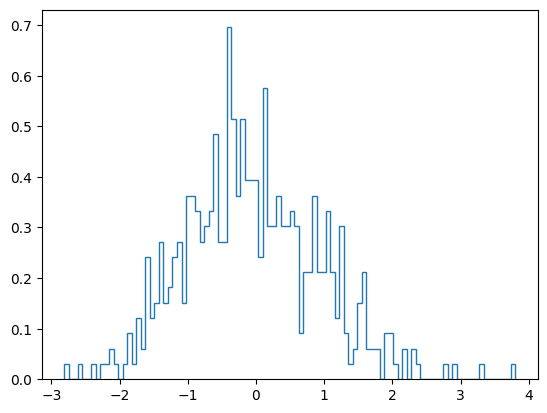

In [18]:
import numpy as np
from scipy.stats import shapiro
from numpy.random import randn

gfg_data = randn(500)
print(gfg_data[:5])

from matplotlib import pyplot as plt
plt.hist(gfg_data, bins = 100, density = True, histtype = "step")

In [19]:
# Lets actually do the test now, i was just curious about what randn did

shapiro(gfg_data)

ShapiroResult(statistic=np.float64(0.9925223714922861), pvalue=np.float64(0.013298081166169588))

Here our p value is 0.013, this is less than 0.05 hence we reject the null hypothesis.

ShapiroResult(statistic=np.float64(0.966902132312346), pvalue=np.float64(0.00011927794577221817))

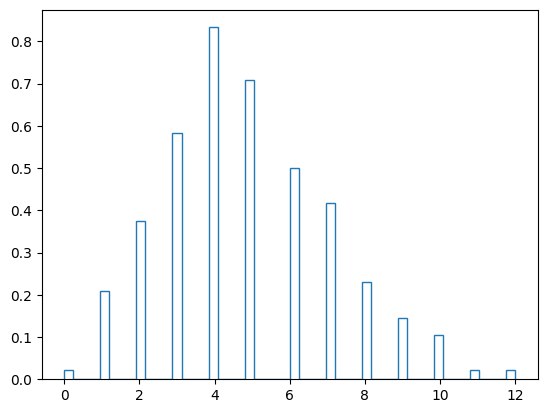

In [24]:
from numpy.random import poisson,seed
seed(0)

gfg_data = poisson(5,200)
plt.hist(gfg_data, bins = 50, density = True, histtype = "step")

shapiro(gfg_data)

### How do we detect extreme outliers?

When a dataset contains a very very small fraction of extreme outliers, e.g. cosmic rays hitting a camera sensor, the sample variance, $s$, gets heavily inflated because it squares the distance of every point from the mean:

$$\qquad \qquad s = \sqrt{\frac{1}{N-1}\sum^N_{i=1}(x_i-\overline{x})^2} \qquad \qquad $$

To detect this, we compare this with $\sigma_G = 0.7413(q_{75} - q_{25}).$

Even when the outlier fraction is tiny, the ratio $s/\sigma_G$ can become significantly large. 

For a Gaussian distribution, $s \approx \sigma _G$ so the ratio is approximately 1.

#### For large samples N > 100, we can use:

$$Z_1 = 1.3\frac{|\mu-q_{50}|}{s}\sqrt{N}$$

And

$$Z_2= 1.1\bigg|\frac{s}{\sigma_G}-1\bigg|\sqrt{N}$$

Where $Z_1$ measures the skewness, and compares the mean and the median. In a symmetric normal distribution, $Z_1$ = 0

$Z_2$ measures how much the standard deviation exceeds the interquartile spread

If either Z is larger than several standard deviations, then we can reject the null hypothesis.


#### The following is an example for all the tests being applied to a sample of 10,000 for a Gaussian distribution

C:\Users\krist\AppData\Local\Temp\ipykernel_31604\1570927303.py:29: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  A2, sig, crit = stats.anderson(vals[i])
C:\Users\krist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Curren

______________________________________________________________________
  Kolmogorov-Smirnov test: D = 0.0076  p = 0.6 
  Anderson-Darling test: A^2 = 0.29
    significance  | critical value 
    --------------|----------------
    0.56          | 15.0%
    0.63          | 10.0%
    0.75          | 5.0%
    0.87          | 2.5%
    1.03          | 1.0%
  Shapiro-Wilk test: W = 1 p = 0.59
  Z_1 = 0.2
  Z_2 = 1.0
______________________________________________________________________
  Kolmogorov-Smirnov test: D = 0.28  p = 0 
  Anderson-Darling test: A^2 = 1.9e+02
    significance  | critical value 
    --------------|----------------
    0.56          | 15.0%
    0.63          | 10.0%
    0.75          | 5.0%
    0.87          | 2.5%
    1.03          | 1.0%
  Shapiro-Wilk test: W = 0.94 p = 7.5e-52
  Z_1 = 32.2
  Z_2 = 2.5


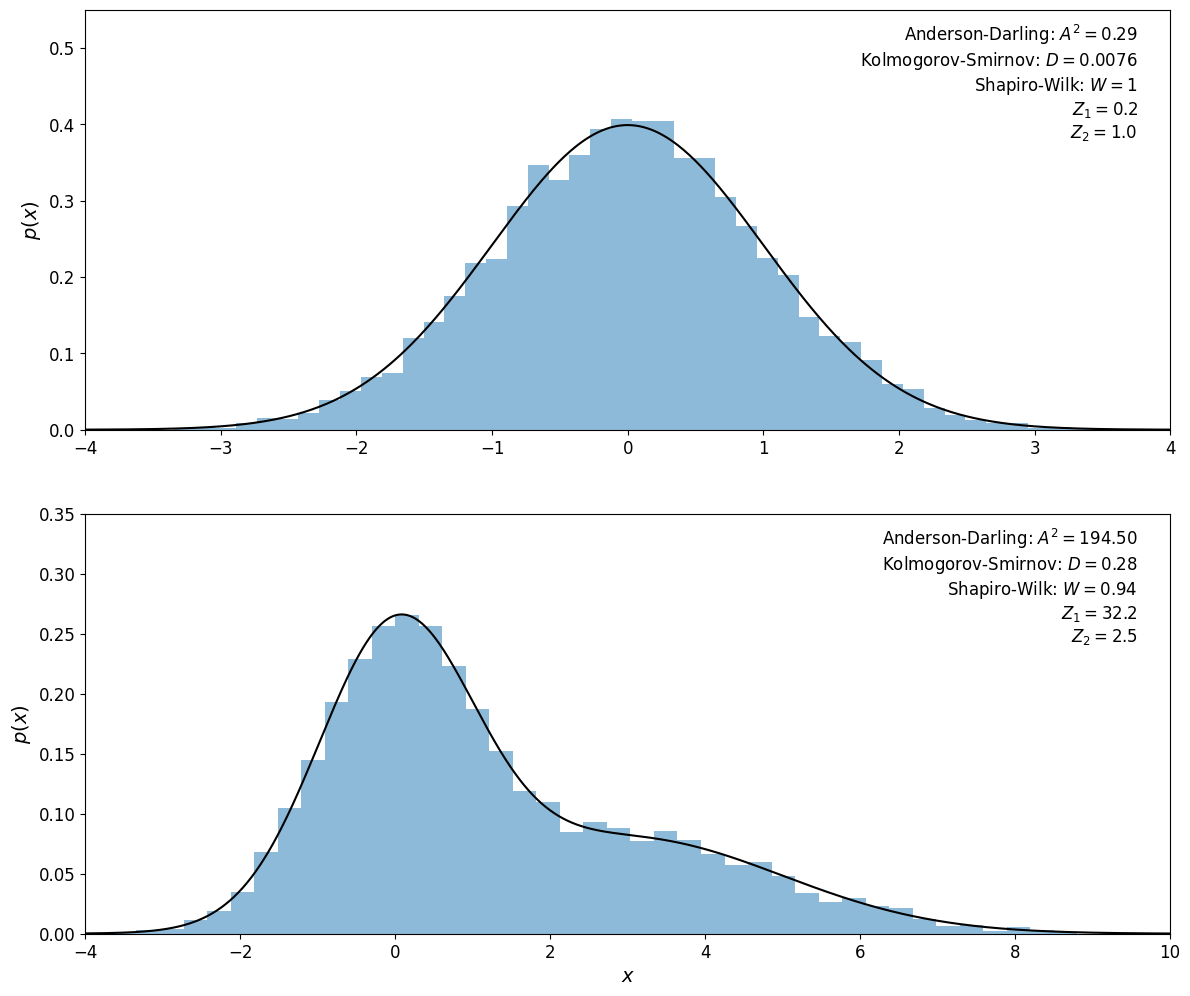

In [25]:
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
from astroML.stats import mean_sigma, median_sigmaG

# create distributions
np.random.seed(1)
normal_vals = stats.norm(0, 1).rvs(10000) # singular Gaussian

dual_vals = stats.norm(0, 1).rvs(10000)
dual_vals[:4000] = stats.norm(3,2).rvs(4000) # mixture of two Gaussians

x = np.linspace(-4, 10, 1000)
normal_pdf = stats.norm(0, 1).pdf(x) # pdf for singular Gaussian
dual_pdf = 0.6 * stats.norm(0, 1).pdf(x) + 0.4 * stats.norm(3, 2).pdf(x) #pdf for mixture of two Gaussians

vals = [normal_vals, dual_vals]
pdf = [normal_pdf, dual_pdf]
xlims = [(-4, 4), (-4, 10)]

#------------------------------------------------------------
# Compute the statistics and plot the results
fig = plt.figure(figsize=(14, 12))

for i in range(2):
    ax = fig.add_subplot(2,1,i+1)

    # compute statistics
    A2, sig, crit = stats.anderson(vals[i]) 
    D, pD = stats.kstest(vals[i], "norm")  
    W, pW = stats.shapiro(vals[i])  
    
    mu, sigma = mean_sigma(vals[i], ddof=1)
    median, sigmaG = median_sigmaG(vals[i])

    N = len(vals[i])
    Z1 = 1.3 * abs(mu - median) / sigma * np.sqrt(N)
    Z2 = 1.1 * abs(sigma / sigmaG - 1) * np.sqrt(N)

    # display results in a table
    print(70 * '_')
    print("  Kolmogorov-Smirnov test: D = %.2g  p = %.2g " % (D, pD))
    print("  Anderson-Darling test: A^2 = %.2g" % A2)
    print("    significance  | critical value ")
    print("    --------------|----------------")
    for j in range(len(sig)):
        print("    {0:.2f}          | {1:.1f}%".format(sig[j], crit[j]))
    print("  Shapiro-Wilk test: W = %.2g p = %.2g" % (W, pW))
    print("  Z_1 = %.1f" % Z1)
    print("  Z_2 = %.1f" % Z2)

    # plot a histogram
    ax.hist(vals[i], bins=50, density=True, histtype='stepfilled', alpha=0.5)
    ax.plot(x, pdf[i], '-k')
    ax.set_xlim(xlims[i])

    # print information on the plot
    info = "Anderson-Darling: $A^2 = %.2f$\n" % A2
    info += "Kolmogorov-Smirnov: $D = %.2g$\n" % D
    info += "Shapiro-Wilk: $W = %.2g$\n" % W
    info += "$Z_1 = %.1f$\n$Z_2 = %.1f$" % (Z1, Z2)
    ax.text(0.97, 0.97, info, ha='right', va='top', 
            transform=ax.transAxes, fontsize = 12)

    if i == 0:
        ax.set_ylim(0, 0.55)
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)
    else:
        ax.set_ylim(0, 0.35)
        ax.set_xlabel('$x$', fontsize = 14)
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)
        
    ax.set_ylabel('$p(x)$', fontsize = 14)

plt.show()

This seems like an all inclusive test for if the distribution is normal, which can be pretty useful in the future.

#### Parametric methods for comparing distributions

Lets say we have a sample that doesn't fail any test for Gaussianity, we can use a few standard tests for comparing means and variances

##### The t test

The student's t test finds whether the means of two Gaussian distributions are very different.

If we know the standard deviation in advance, we can:
1. Compute the sample means
2. Compute the standard error of the differences:

$$\sigma_\Delta = \sigma\sqrt{1/N_1^2+1/N_2^2}$$
3. Measure the difference in the means in terms of the expected scatter

$$M_\sigma = \Delta/ \sigma_\Delta$$

4. The probability that the obsreved value of M would arise by chance is given by the Gauss error function:

$$p = 1-\text{erf}(M/\sqrt{2})$$


###### What if we don't know the std?

If we don't know $\sigma$ and it must be estimated from the data using sample std, then the ratio:

$$M_s = \frac{\Delta}{s_{\Delta}}$$

where $s_\Delta = \sqrt{s_1^2/N_1 + s_2^2/N_2}$ can no longer be described by Gaussianity and instead it follows the student t distribution.

The number of degrees of freedom depeonds on whether we assume that the two distributions from which the samples were drawn have the same variances. If we can make this assumption, then the statistic is 

$$\qquad \qquad \qquad t=\frac{\overline{x1}-\overline{x2}}{s_D}\qquad \qquad \qquad $$

Where,

$$\qquad \qquad s_D = \sqrt{s^2_{12}\bigg(\frac{1}{N_1}+\frac{1}{N_2}\bigg)} \qquad \qquad s_{12} = \sqrt{\frac{(N_1-1)s^2_1+(N_2-1)s^2_2}{N_1+N_2-2}}$$

The denominator in the statistic represents how much fluctuation we would naturally expect between two sample means by random chance. The numerator is the observed difference between the average of the samples.

If t $\approx$ 0 then we have no real difference.

##### Python implementation

In [26]:
import numpy as np
from scipy import stats

np.random.seed(0)
rvs1 = stats.norm.rvs(2, 8, 500)
rvs2 = stats.norm.rvs(2, 8, 500) + stats.norm.rvs(0,0.2,500)
print(stats.ttest_ind(rvs1, rvs2))

rvs3 = stats.norm.rvs(6, 8, 500)+ stats.norm.rvs(0,0.2,500)
print(stats.ttest_ind(rvs1, rvs3))

TtestResult(statistic=np.float64(0.625416390541633), pvalue=np.float64(0.5318407886123995), df=np.float64(998.0))
TtestResult(statistic=np.float64(-8.378738664093502), pvalue=np.float64(1.8000707268010126e-16), df=np.float64(998.0))


#### Selection effects and Luminosity function estimation

Here I will copy what I had so far for this from yesterday:

Now lets look at truncated and censored data, this can happen due to observational limits.

When the selection function $S(x)$ is known and finite, we can use it to correctly estimate the observed density $f(x)$ to get the true underlying distribution:

$$h(x) = \frac{f(x)}{S(x)}$$


Assume that in addition to $x$, we also measure a quantity $y$, and that our selection function is such that $S(x) = 1$ for $0 \le y \le y_{\text{max}}(x)$, and $S(x) = 0$ for $y > y_{\text{max}}(x)$, with $x_{\text{min}} \le x \le x_{\text{max}}$. Here, the observable $y$ may or may not be related to observable $x$, and the $y \ge 0$ assumption is added for simplicity and without a loss of generality.

We can think of x as the absolute magnitude and y as distance or redshift.

For this example we can compute something like:

$$y_\text{max}(x) = (x/(4\pi F_\text{min}))^{1/2}$$

Where $F_min$ is the smallest flux that our measuring appratus can detect.

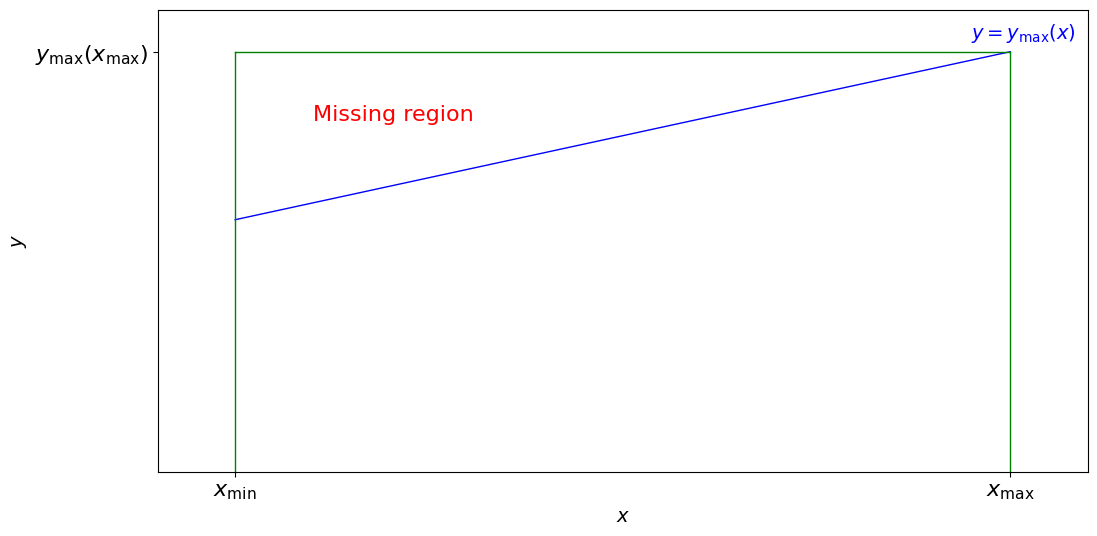

In [28]:
import numpy as np
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(12, 6))
max_func = lambda t: 0.4*t+0.6
x = np.linspace(0, 1.0, 100)
ymax = max_func(x)
ymax[ymax > 1] = 1

# plot func and lines
plt.plot(x, ymax, 'b', lw=1)
plt.plot([0, 1], [1, 1], 'g', lw=1)
plt.plot([1, 1], [0, 1], 'g', lw=1)
plt.plot([0, 0], [0, 1], 'g', lw=1)

# add text
plt.text(0.95, 1.03, r'$y = y_{\rm max}(x)$',color = 'b',fontsize = 14)
plt.text(0.1, 0.85, r'Missing region', color = 'r', ha='left', va='center', fontsize = 16)

# adjust the limits
plt.xlim(-0.1, 1.1)
plt.ylim(0, 1.1)
plt.xticks([0,1],[r'$x_{\rm min}$',r'$x_{\rm max}$'],fontsize = 16)
plt.yticks([1],[r'$y_{\rm max}(x_{\rm max})$'],fontsize = 16)
plt.xlabel('$x$', fontsize = 14)
plt.ylabel('$y$', fontsize = 14)

plt.show()

The blue boundary shows the maximum distance at which an object with intrinsic property x can still be detected given the instruments minimum sensitivity threshold.

The missing region are the points that exist in reality but are unobserved.

So how do we express the true distribution vs the observed distribution due to this missing region?

If there was no observational cutoff, $S(x) = 1$, then:

$$h(x) = \int^{y_\text{max}(x_\text{max})}_0 n(x,y) \: dy$$

Where $n(x,y)$ is the probability density.

For the observed distribution, we can only see up to $y_{max}(x)$ hence, 

$$f(x) = \int^{y_\text{max}(x)}_{0} n(x,y) \: dy$$

Now theres a slight challenge here, the difference between $f(x)$ and $h(x)$ depends heavily on how $n(x,y)$ behaves. Hence to recover h(x) we need to first estimate n(x,y).

Hence, 
1. Given a set of measured pairs $(x_i, y_i)$ and a known relation $y_{max}(x)$ estimate the 2D distribution n(x,y) from which the sample was drawn
2. Assume that the measurement errors for both x and y are negligible compared to their observed ranges, that x is measured within x_min and x_max. And that the selection function is 1 between $0 \leq y \leq y_\text{max}(x)$ and $x_\text{min} \leq x \leq x_\text{max}$ and 0 otherwise.

### Lynden Bell $C^{-1}$ method

The Lynden Bell method is a nonparametric statistical technique designed to reconstruct the true underlying probability distribution of a dataset that suffers from selection effects like truncation.

It works when we can assume the bivariate distribution is separable (independant):

$$n(x,y) = \Psi(x)\rho(y)$$

To test if a bivariate distribution is seperable you can do the following:

1. For each data point $i = (x_i, y_i)$, construct its associated subset $J_i$. This is the largest x-limited and y-limited data subset for object $i$, with $N_i$ elements

$$J_i = \{j: x_j < x_i, y_j < y_\text{max}(x_i)\}$$

2. Sort the $J_i$ by $y_j$. This gives the rank R_j for each object. (This ranges from 1 to $N_i$)
3. Define the rank $R_i$ for object $i$ in its associated set
4. If x and y are truly independant, $R_i$ must be distributed normally between 0 and $N_i$. From here wwe can determine its expectation and variance 

$$R_i: E(R_i) = E_i = N_i/2 \qquad \qquad \qquad V(R_i) = V_i = N_i^2/12$$

And we can define the test statistic:

$$\tau = \frac{\sum_i(R_i-E_i)}{\sqrt{\sum_iV_i}}$$

If $\tau < 1$ then x and y are uncorrelated at roughly the $1\sigma$ level, this validates the separability assumption

Assuming the above is true then the CDF is defined as:


$$\Phi(x) = \int^x_{-\infty} \Psi (x^\prime)\:dx^\prime$$

and 

$$\Sigma (y) = \int^y_{-\infty} \rho(y^\prime)\:dy^\prime.$$

Then 

$$\Phi (x_i) = \Phi (x_1)\prod^i_{k=2}(1+1/N_k)$$

And

$$\Sigma(y_j) = \Sigma(y_1) \prod ^j_{k=2}(1+1/M_k)$$

Where $M_k$ represents the size of analagous associated sets $J_k$ along $y$

From this (which has been very difficult to understand at this point, I think I need to revisit this)

But the continous differential density distributions $\Psi(x), \rho(x)$ can be derived by binning the cumulative step functions, $\Phi(x)$, $\Sigma(y)$. With uncertainties estimated via bootstrap or standard histogram noise formulas.

Now lets attempt to look at an application...

In [29]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from astroML.lumfunc import bootstrap_Cminus

#------------------------------------------------------------
# Define and sample our distributions
N = 10000
np.random.seed(42)

# Define the input distributions for x and y
x_pdf = stats.truncnorm(-2, 1, 0.66666, 0.33333)
y_pdf = stats.truncnorm(-1, 2, 0.33333, 0.33333)

x = x_pdf.rvs(N)
y = y_pdf.rvs(N)

# define the truncation as discussed above
max_func = lambda t: 1. / (0.5 + t) - 0.5

xmax = max_func(y)
xmax[xmax > 1] = 1  # cutoff at x=1

ymax = max_func(x)
ymax[ymax > 1] = 1  # cutoff at y=1

# truncate the data
flag = (x < xmax) & (y < ymax)
x = x[flag]
y = y[flag]
xmax = xmax[flag]
ymax = ymax[flag]

x_fit = np.linspace(0, 1, 21)
y_fit = np.linspace(0, 1, 21)

#------------------------------------------------------------
# compute the Cminus distributions (with bootstrap)
x_dist, dx_dist, y_dist, dy_dist = bootstrap_Cminus(x, y, xmax, ymax,
                                                    x_fit, y_fit,
                                                    Nbootstraps=20,
                                                    normalize=True)

x_mid = 0.5 * (x_fit[1:] + x_fit[:-1])
y_mid = 0.5 * (y_fit[1:] + y_fit[:-1])

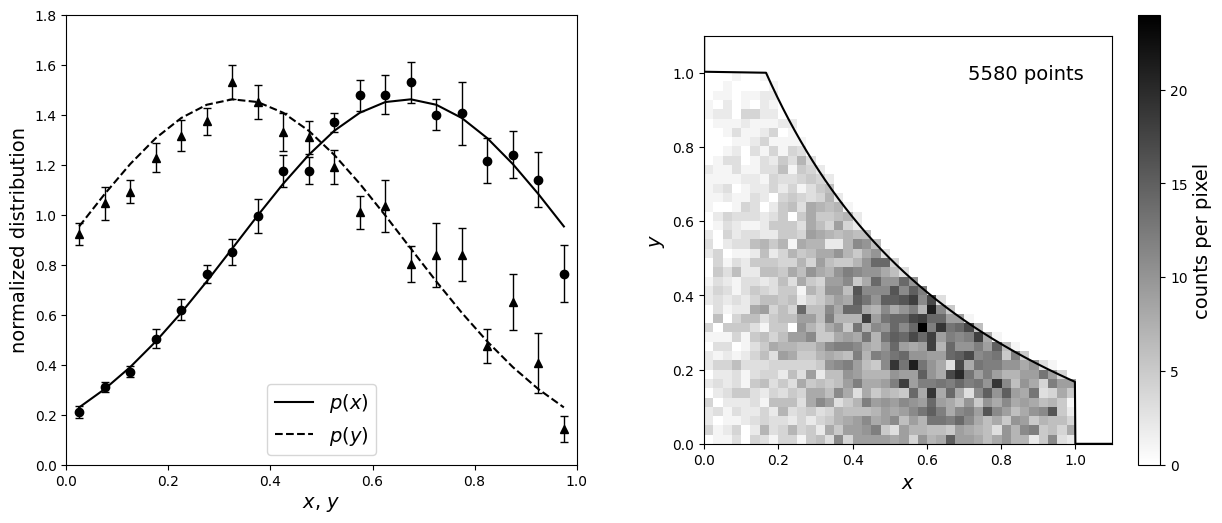

In [30]:
fig = plt.figure(figsize=(14, 6))
fig.subplots_adjust(bottom=0.2, top=0.95,
                    left=0.1, right=0.92, wspace=0.25)

# First subplot is the true & inferred 1D distributions
ax = fig.add_subplot(121)
ax.plot(x_mid, x_pdf.pdf(x_mid), '-k', label='$p(x)$')
ax.plot(y_mid, y_pdf.pdf(y_mid), '--k', label='$p(y)$')
ax.legend(loc='lower center' , fontsize= 14)

ax.errorbar(x_mid, x_dist, dx_dist, 
            fmt='ok', ecolor='k', lw=1, ms=6, capsize = 3)
ax.errorbar(y_mid, y_dist, dy_dist, 
            fmt='^k', ecolor='k', lw=1, ms=6, capsize = 3)

ax.set_ylim(0, 1.8)
ax.set_xlim(0, 1)
ax.set_xlabel('$x$, $y$', fontsize= 14)
ax.set_ylabel('normalized distribution', fontsize= 14)

# Second subplot is the "observed" 2D distribution
ax = fig.add_subplot(122)
H, xb, yb = np.histogram2d(x, y, bins=np.linspace(0, 1, 41))
plt.imshow(H.T, origin='lower', interpolation='nearest',
           extent=[0, 1, 0, 1], cmap=plt.cm.binary)
cb = plt.colorbar()

x_limit = np.linspace(-0.1, 1.1, 1000)
y_limit = max_func(x_limit)
x_limit[y_limit > 1] = 0
y_limit[x_limit > 1] = 0
ax.plot(x_limit, y_limit, '-k')

ax.set_xlim(0, 1.1)
ax.set_ylim(0, 1.1)
ax.set_xlabel('$x$', fontsize= 14)
ax.set_ylabel('$y$', fontsize= 14)
cb.set_label('counts per pixel', fontsize= 14)
ax.text(0.93, 0.93, '%i points' % len(x), ha='right', va='top',
        transform=ax.transAxes, fontsize= 14)

plt.show()

Here we generated x and y independantly so we know it can be seperable.

It then applies some logic where points are only keptif $x < x_{max}(y)$

My head hurts, I will take a break and do some problems.

### References

[What is the Anderson Darling test, only watched a few mins](https://www.youtube.com/watch?v=xldxEdwv92M&list=PLJWeb5_BSlfN-JjY60DIuYXvDEDlHBfEz)

[Scipy doc for Anderson test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.anderson.html)

[SciPy doc for T test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html)

[Shapiro Wilk test](https://www.geeksforgeeks.org/machine-learning/how-to-perform-a-shapiro-wilk-test-in-python/)